In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from PIL import Image


In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from datetime import datetime
now = datetime.now()
timestampstr = "figures"+now.strftime("%Y%m%d%H%M")

output_dir = os.path.join("/mnt/d/lding/CLS/mousumiLiuDinner",  timestampstr)
os.makedirs(output_dir,exist_ok=True)


In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CSV
data_csv = "/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_mt_strcture_20250310_MA.csv"
image_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results" \
"/Microtubule_GUV-Liu-20250106T211105Z-001/processed_MT/GUV-MT_obj_png_selected_std15"


df = pd.read_csv(data_csv)
df = df.dropna(subset=["filename", "label"])
df["label"] = df["label"].astype(str)

# Split into Train (80%) & Validation (20%)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_df.to_csv(os.path.join(output_dir, "train_split_efficientnotb0_cellpose.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "val_split_efficientnotb0_cellpose.csv"), index=False)

# Define Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Custom Dataset Class
class CustomDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.data = dataframe.copy()
        self.root_dir = root_dir
        self.transform = transform
        self.label_to_index = {label: idx for idx, label in enumerate(sorted(self.data["label"].unique()))}
        self.data["label"] = self.data["label"].map(self.label_to_index)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data.iloc[idx, 0])
        image = Image.open(img_name).convert("RGB")
        label = int(self.data.iloc[idx, 1])
        if self.transform:
            image = self.transform(image)
        return image, label

# Create Datasets & DataLoaders
train_dataset = CustomDataset(train_df, image_dir, transform=train_transform)
val_dataset = CustomDataset(val_df, image_dir, transform=val_transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [5]:

# Load EfficientNet-B0 Model & Modify for Classification
from torchvision.models import efficientnet_b0

model = efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),  # Add dropout to reduce overfitting
    nn.Linear(num_ftrs, len(train_dataset.label_to_index))
)
model = model.to(device)

# Define Focal Loss for better handling of class imbalance
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)  # Probability of correct class
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(alpha=1, gamma=2)

# Use AdamW optimizer with weight decay for better generalization
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=1e-4)

# Learning rate scheduler to adjust learning rate dynamically
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# Training Loop with Early Stopping
num_epochs = 200
best_val_acc = 0
patience = 30
patience_counter = 0
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []




for epoch in range(num_epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
    # print(correct_train)
    # print(total_train)
    train_loss = running_loss / len(train_dataloader)
    train_acc = correct_train / total_train
    
    # Validation Step
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
    
    val_loss = running_val_loss / len(val_dataloader)
    val_acc = correct_val / total_val
    # print(correct_val)
    # print(total_val)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}")
    
    scheduler.step()  # Adjust learning rate
    
    # Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(output_dir,"cleanning_version_cellpose_best_model"+timestampstr+".pth"))
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered. Best Validation Accuracy:", best_val_acc)
            break


/home/ldin/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss = 0.8136, Train Acc = 0.4078, Val Loss = 1.0227, Val Acc = 0.2958
Epoch 2: Train Loss = 0.3712, Train Acc = 0.6489, Val Loss = 0.7883, Val Acc = 0.3521
Epoch 3: Train Loss = 0.1682, Train Acc = 0.7872, Val Loss = 0.5731, Val Acc = 0.4507
Epoch 4: Train Loss = 0.0872, Train Acc = 0.8440, Val Loss = 0.4544, Val Acc = 0.5493
Epoch 5: Train Loss = 0.0463, Train Acc = 0.8901, Val Loss = 0.5188, Val Acc = 0.5634
Epoch 6: Train Loss = 0.0311, Train Acc = 0.9220, Val Loss = 0.4624, Val Acc = 0.5634
Epoch 7: Train Loss = 0.0184, Train Acc = 0.9397, Val Loss = 0.3886, Val Acc = 0.6197
Epoch 8: Train Loss = 0.0190, Train Acc = 0.9433, Val Loss = 0.3529, Val Acc = 0.6479
Epoch 9: Train Loss = 0.0182, Train Acc = 0.9397, Val Loss = 0.3731, Val Acc = 0.6620
Epoch 10: Train Loss = 0.0099, Train Acc = 0.9610, Val Loss = 0.3398, Val Acc = 0.6338
Epoch 11: Train Loss = 0.0063, Train Acc = 0.9645, Val Loss = 0.3343, Val Acc = 0.6479
Epoch 12: Train Loss = 0.0071, Train Acc = 0.9823, V

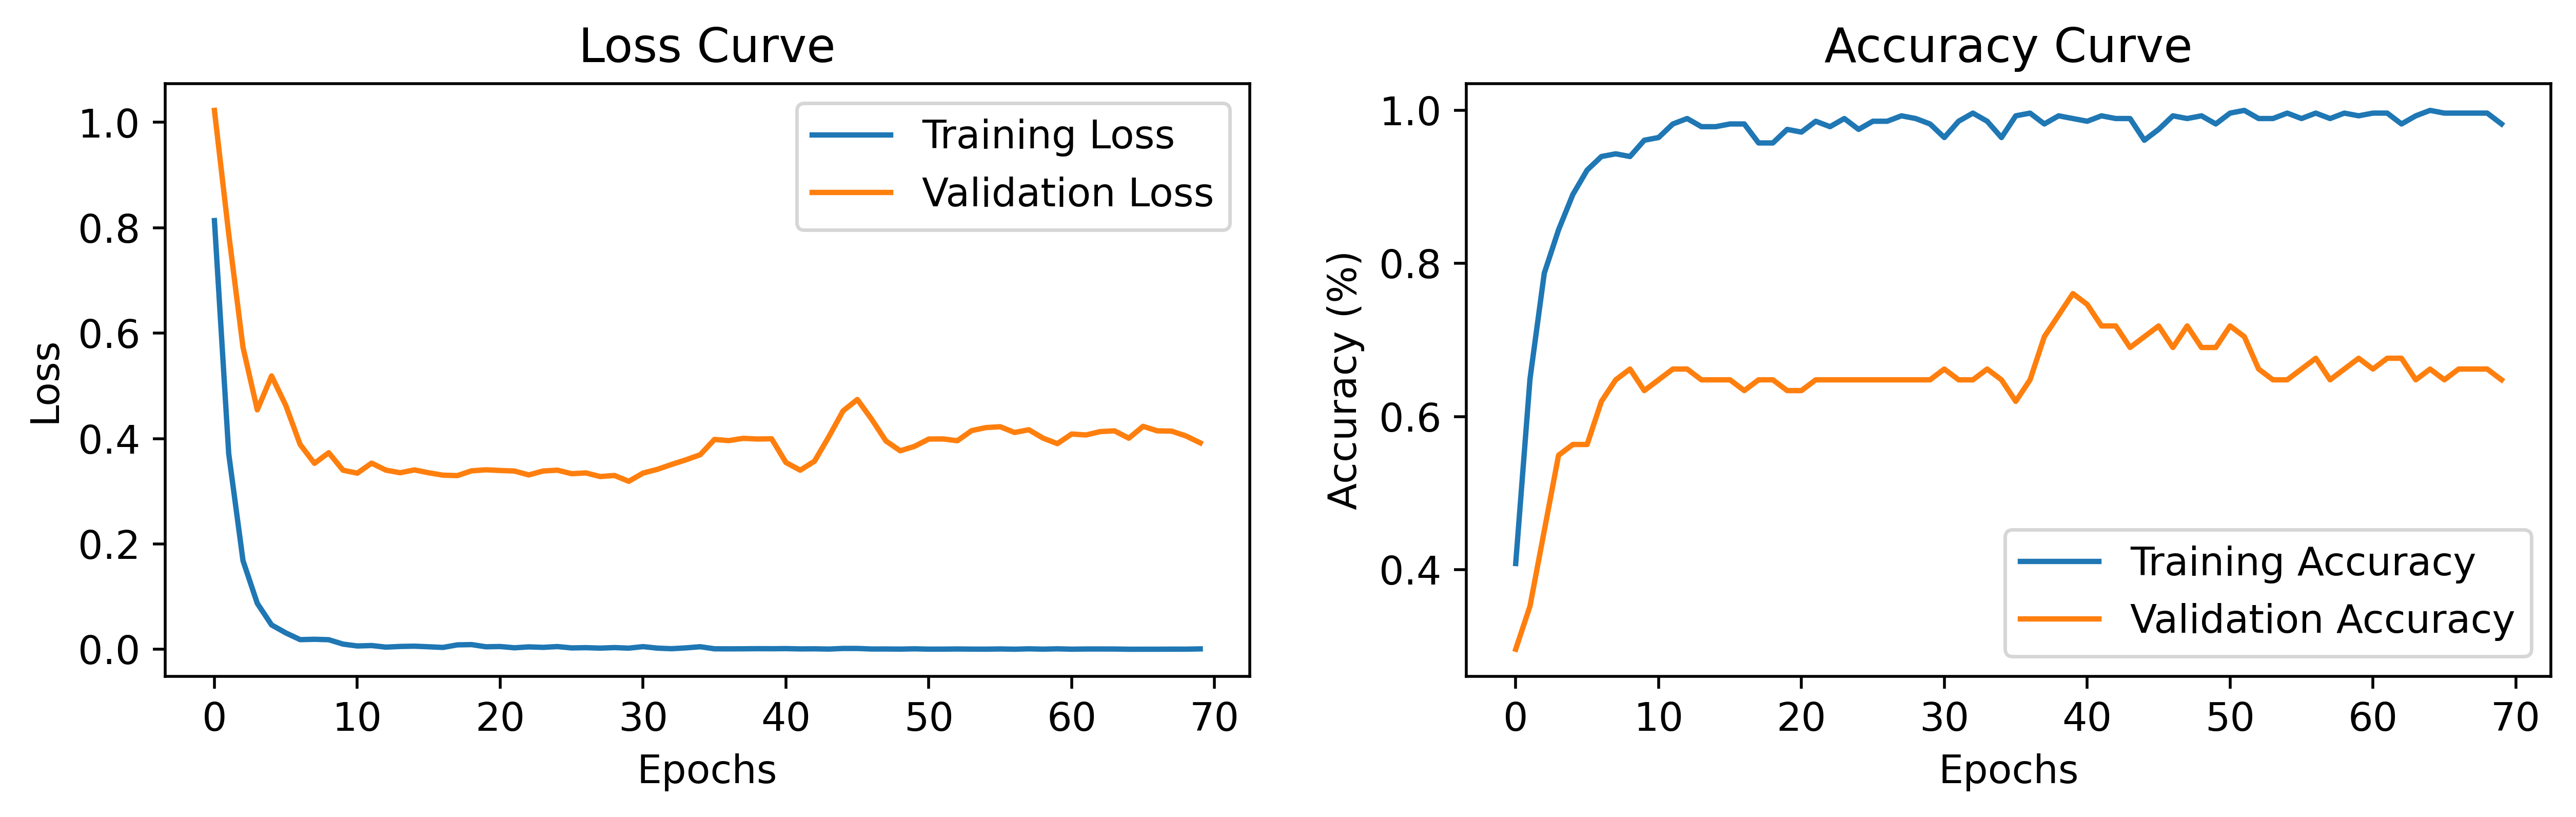

In [6]:
import matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.size'] = 11

# Plot training and validation losses and accuracies
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies,output_dir):
    plt.figure(figsize=(12, 3),dpi=500)    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
        
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.savefig(os.path.join(output_dir, "loss_accu_curve.png"), dpi=500, bbox_inches='tight')
    
    plt.show()    

plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies,output_dir)


In [7]:
# import torchvision.models as models
# import torch.nn as nn
# import torch

# # Set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Function to initialize different models
# def initialize_model(model_name, num_classes):
#     if model_name == "efficientnet":
#         model = models.efficientnet_b0(pretrained=True)
#         num_ftrs = model.classifier[1].in_features
#         model.classifier[1] = nn.Sequential(
#             nn.Dropout(0.3),
#             nn.Linear(num_ftrs, num_classes)
#         )
#     elif model_name == "resnet":
#         model = models.resnet18(pretrained=True)
#         num_ftrs = model.fc.in_features
#         model.fc = nn.Linear(num_ftrs, num_classes)
#     elif model_name == "convnext":
#         model = models.convnext_tiny(pretrained=True)
#         num_ftrs = model.classifier[-1].in_features
#         model.classifier[-1] = nn.Linear(num_ftrs, num_classes)
#     else:
#         raise ValueError("Unsupported model type")
#     return model.to(device)


# # Function to load the best trained model
# def load_best_model(model_name, model_path, num_classes):
#     model = initialize_model(model_name, num_classes)
#     model.load_state_dict(torch.load(model_path))
#     model = model.to(device)
#     model.eval()
#     return model

# model_path = "cleanning_version_cellpose_best_model.pth"
# model = load_best_model("efficientnet", model_path, num_classes=5)


['Cluster', 'Filaments', 'Network', 'Patch', 'Null']
['Cluster', 'Filaments', 'Network', 'Patch', 'Null']


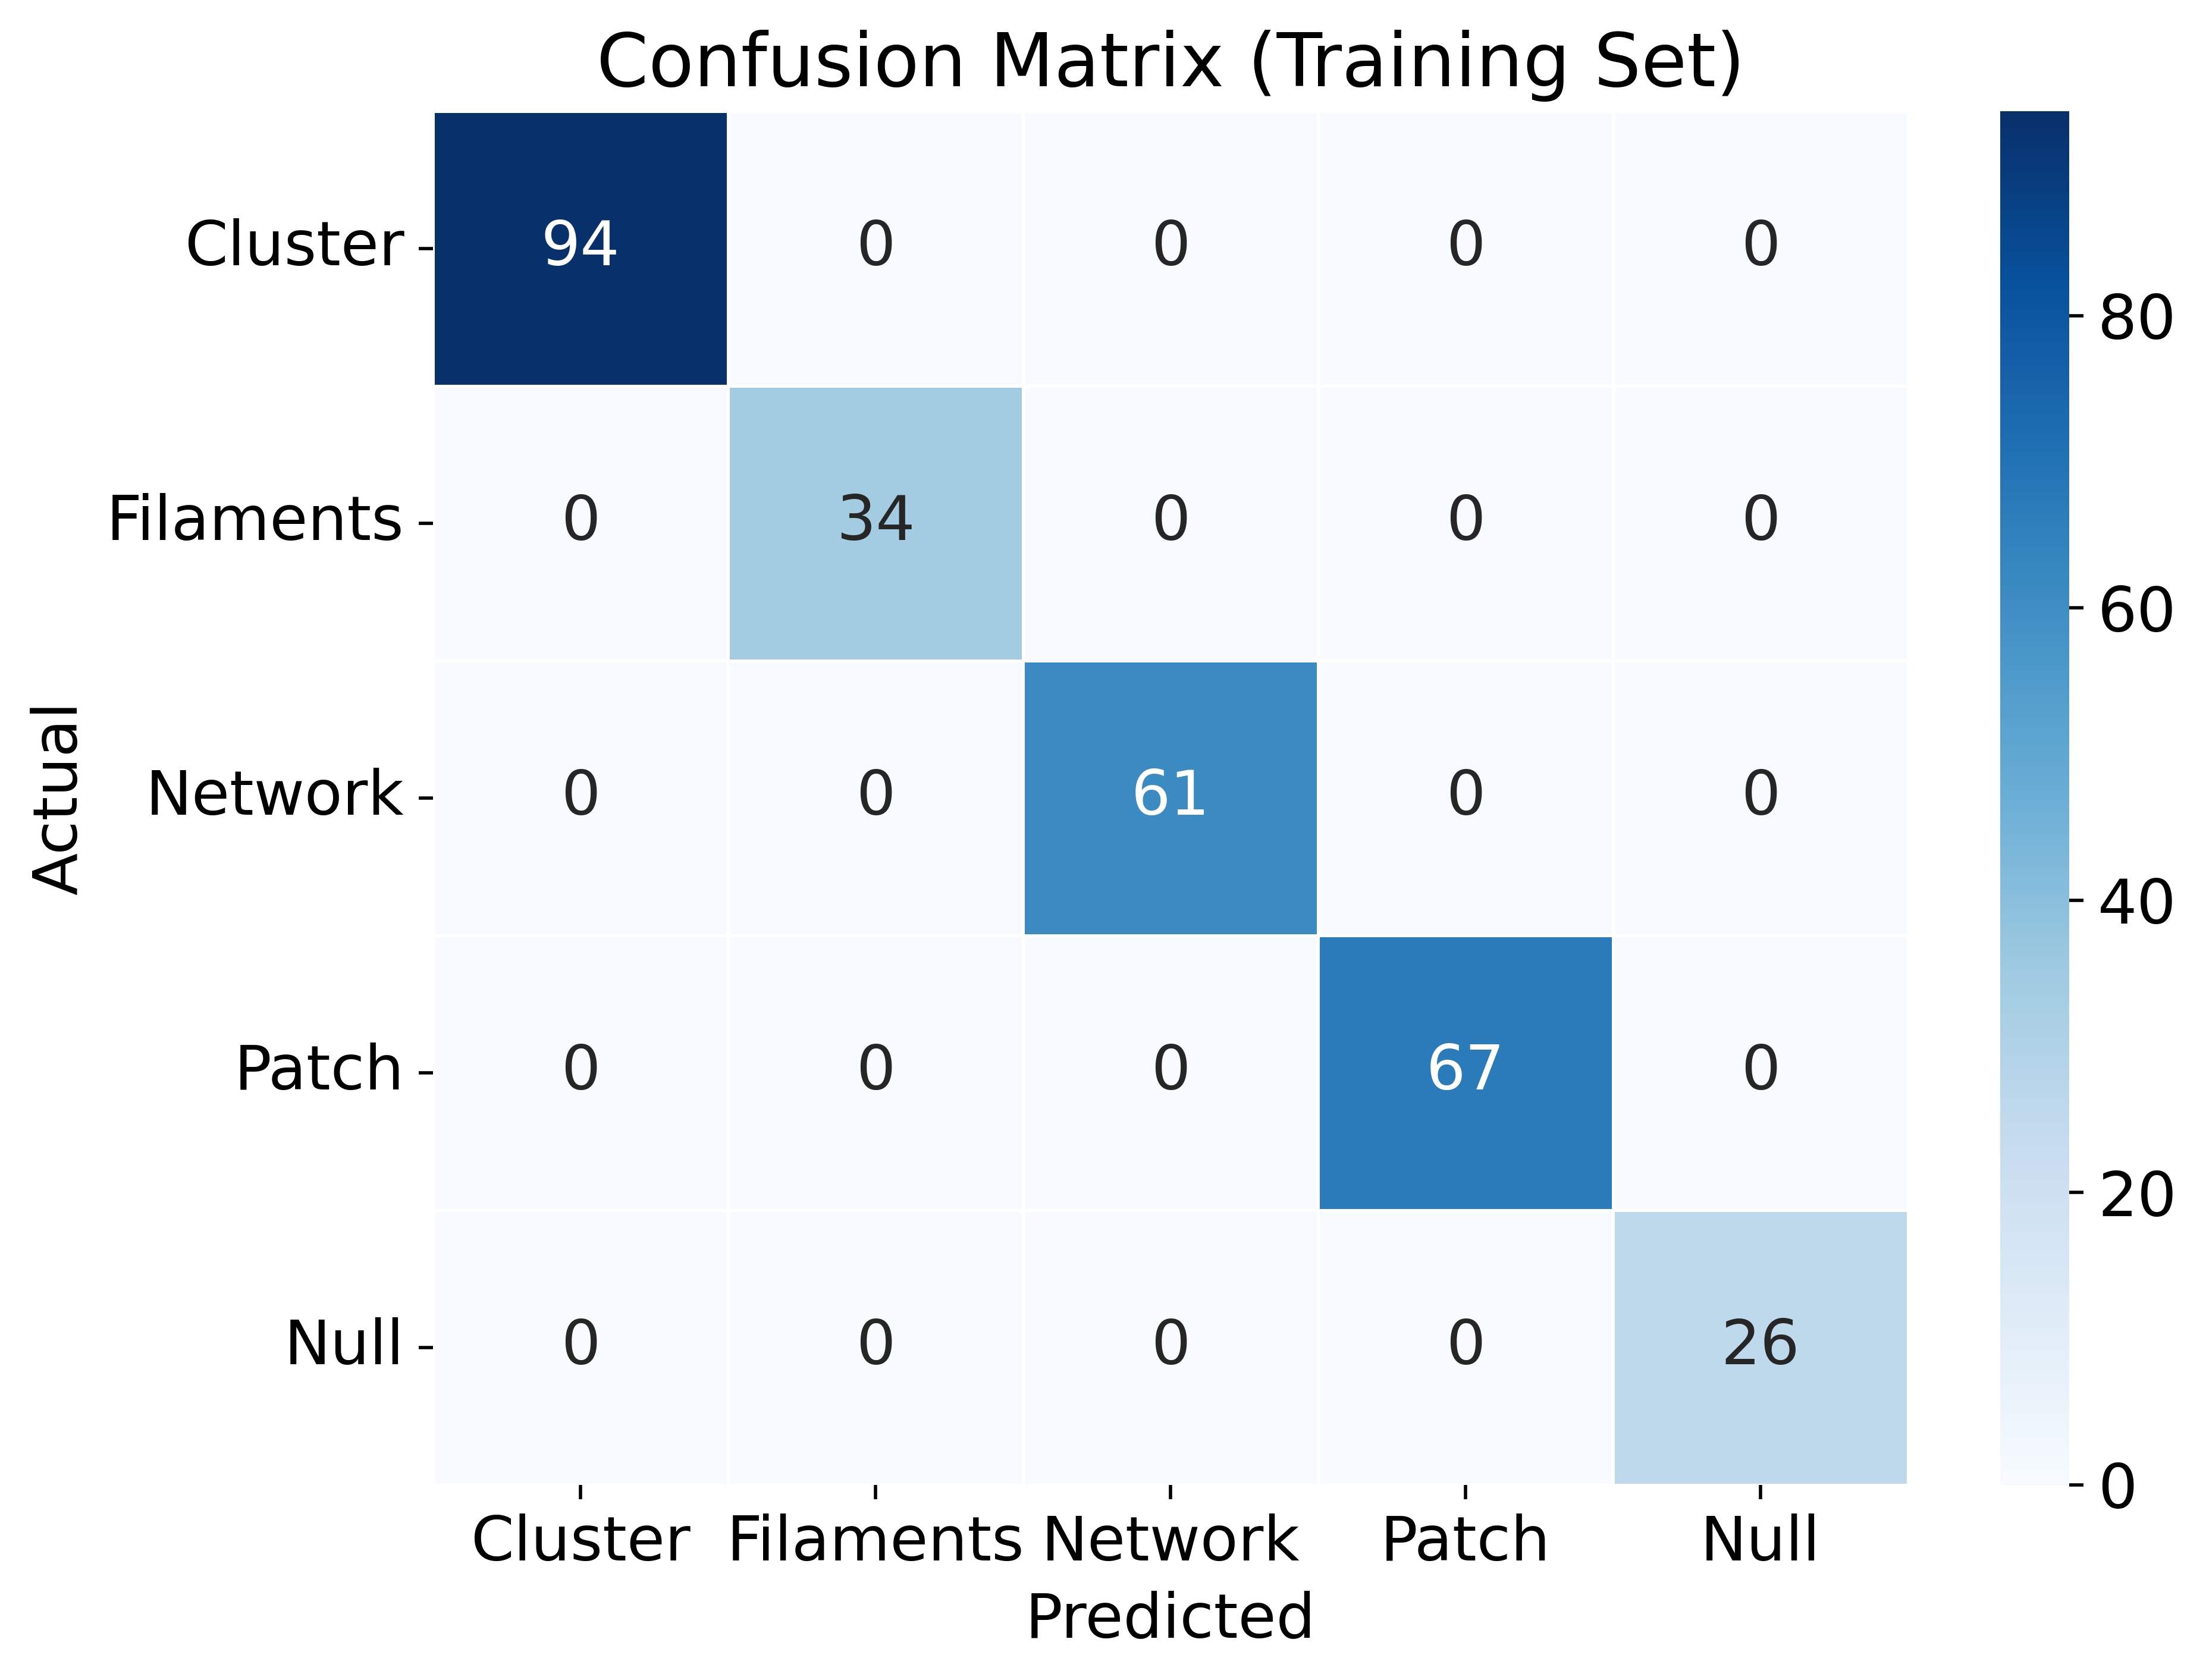

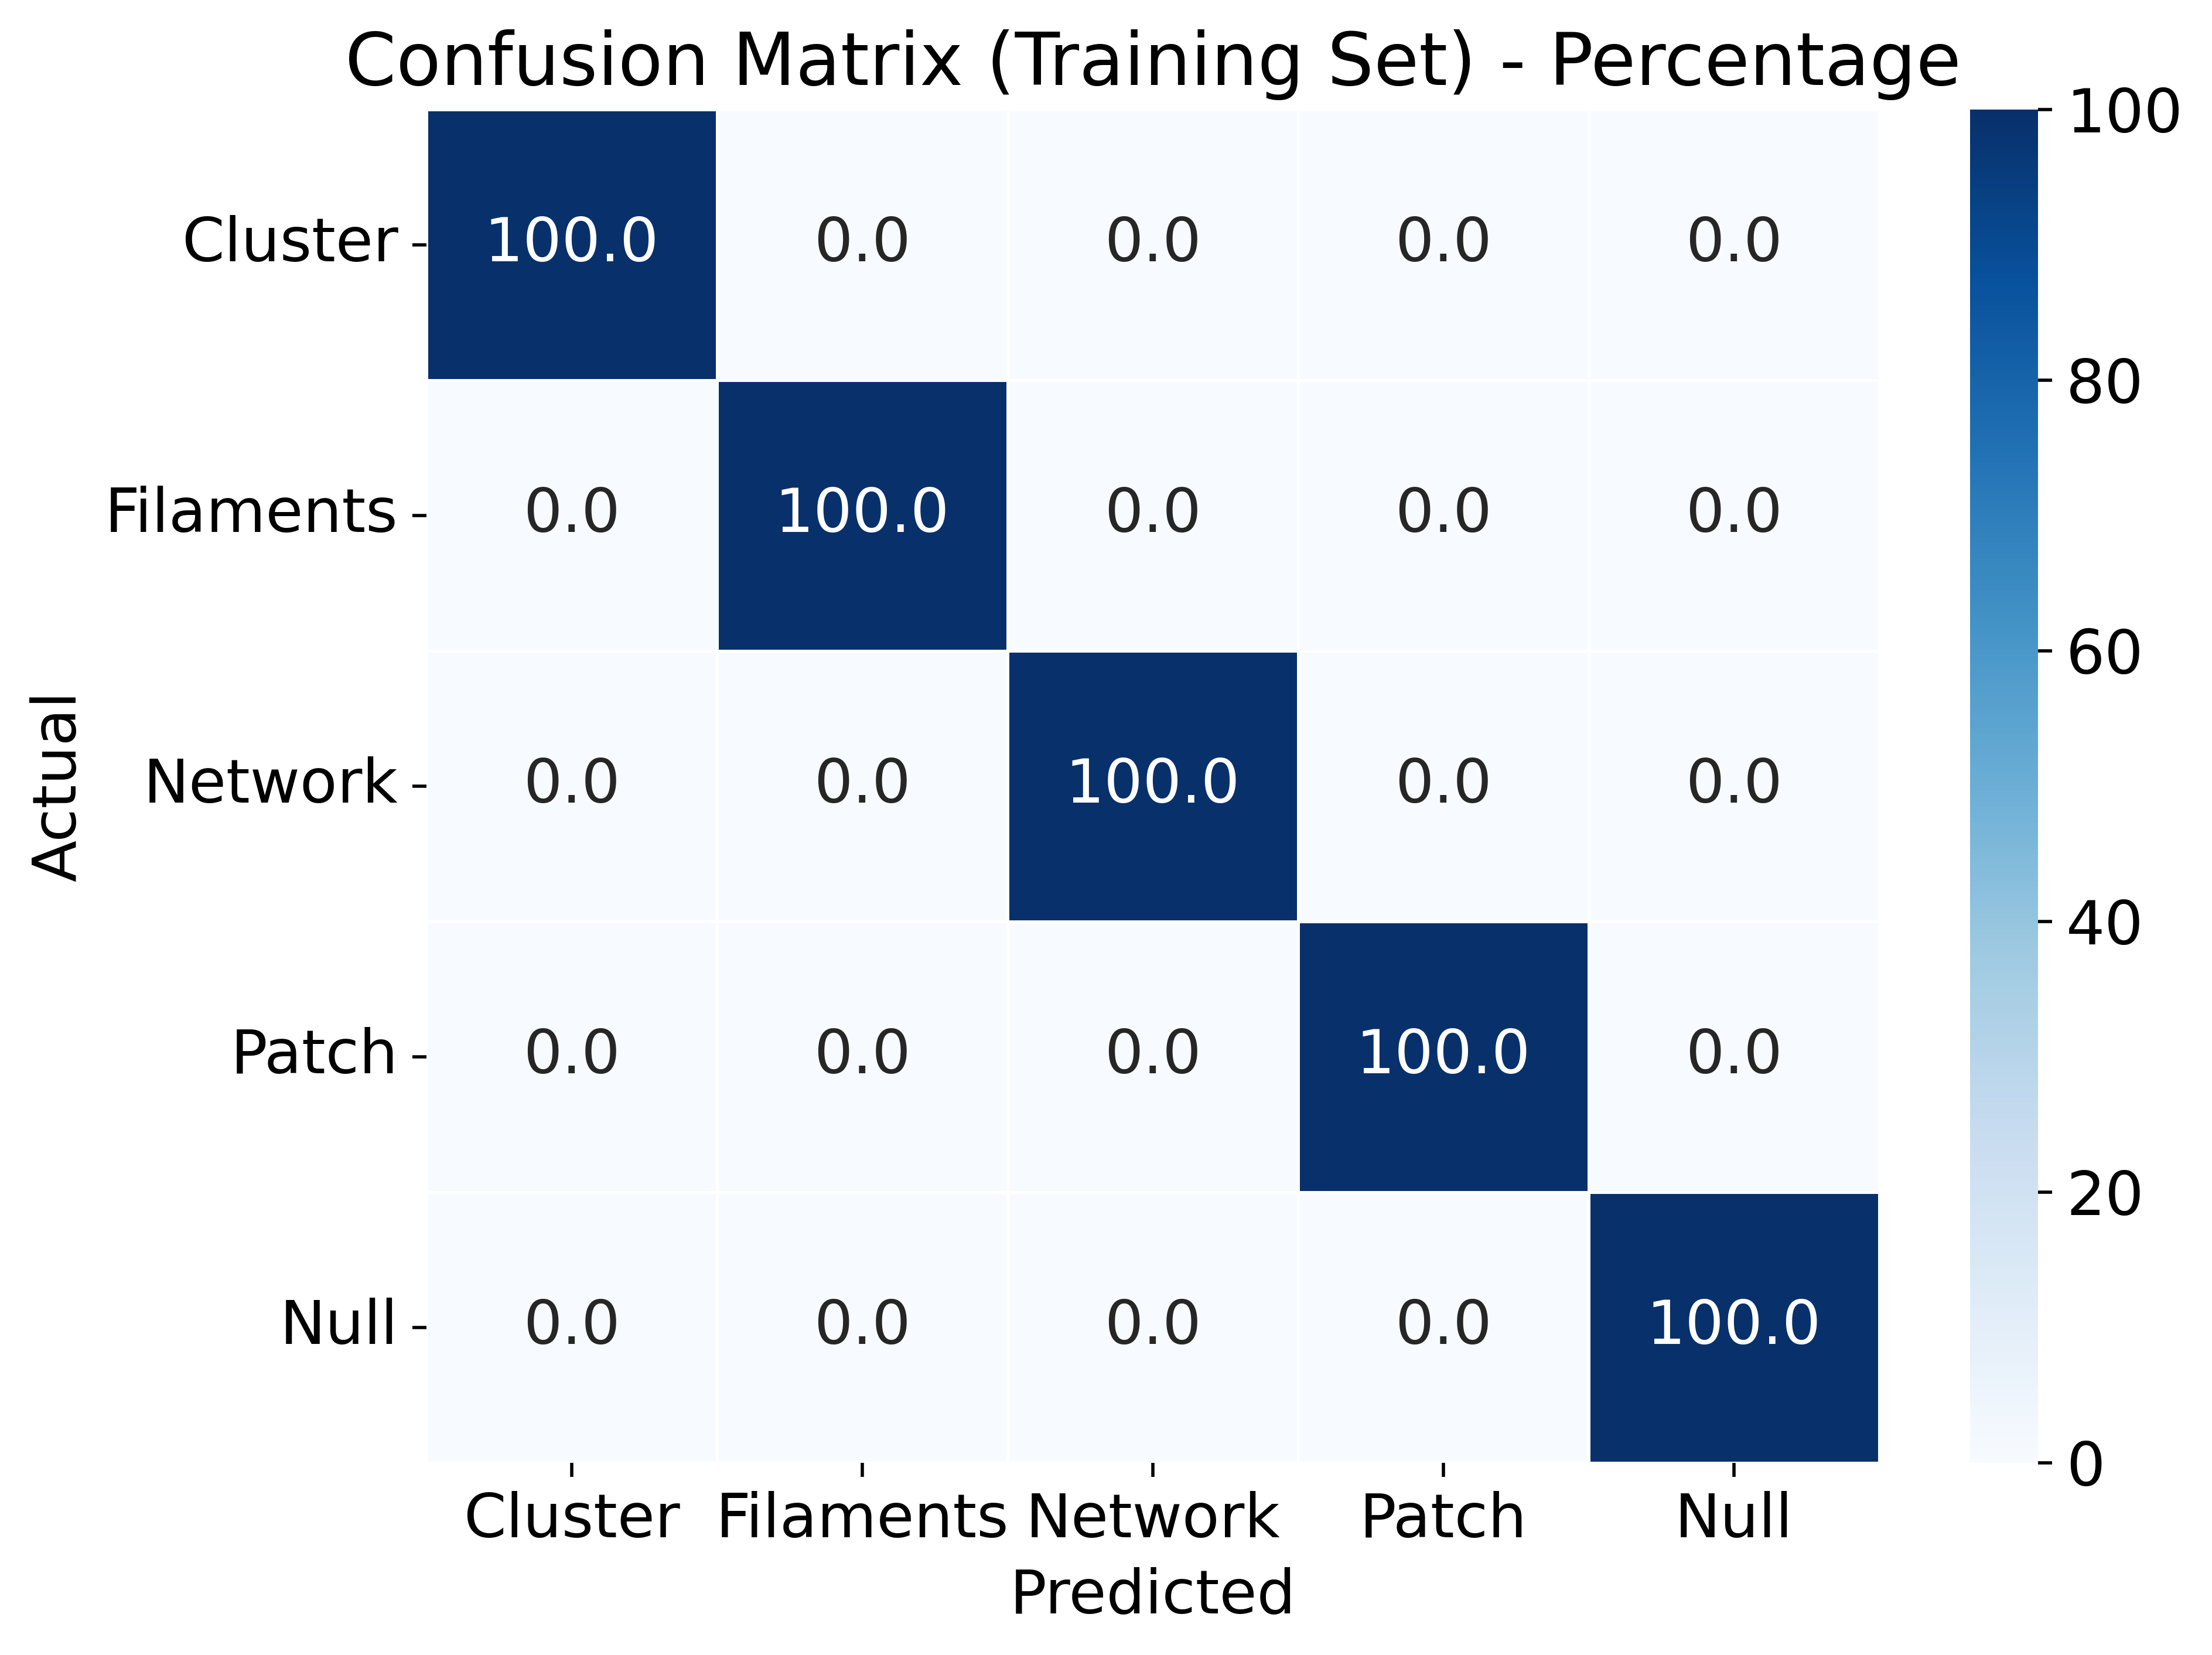

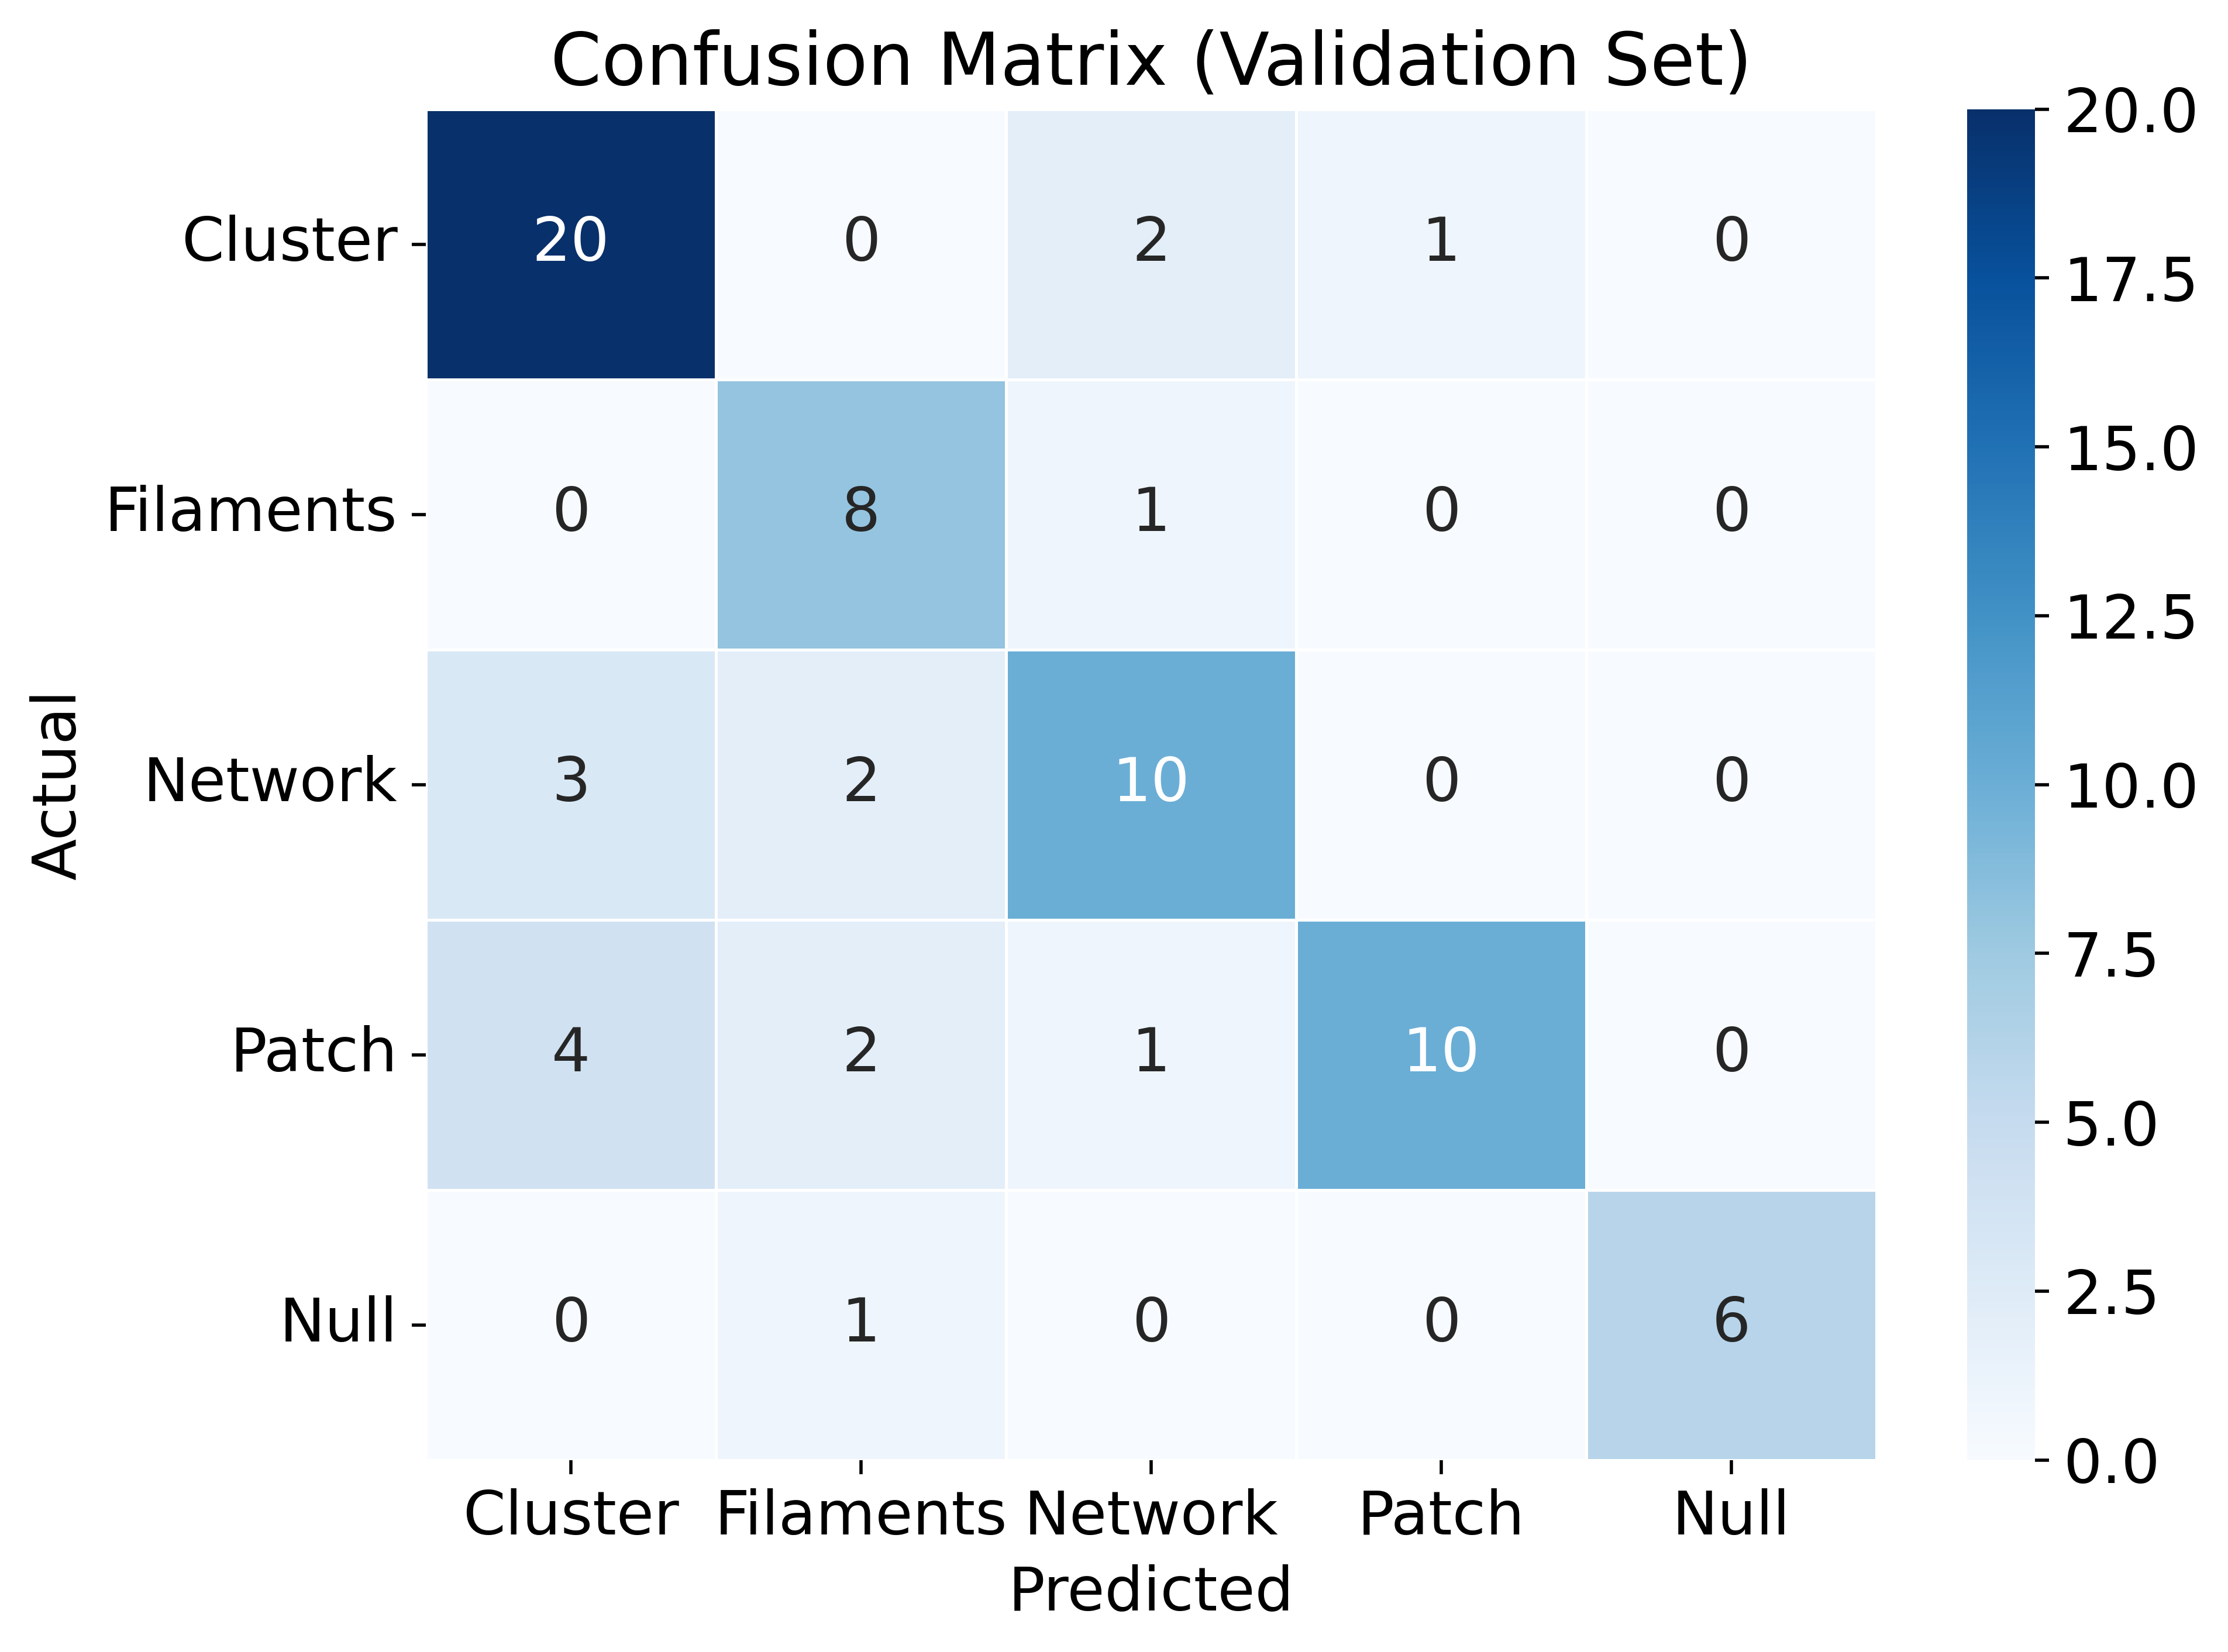

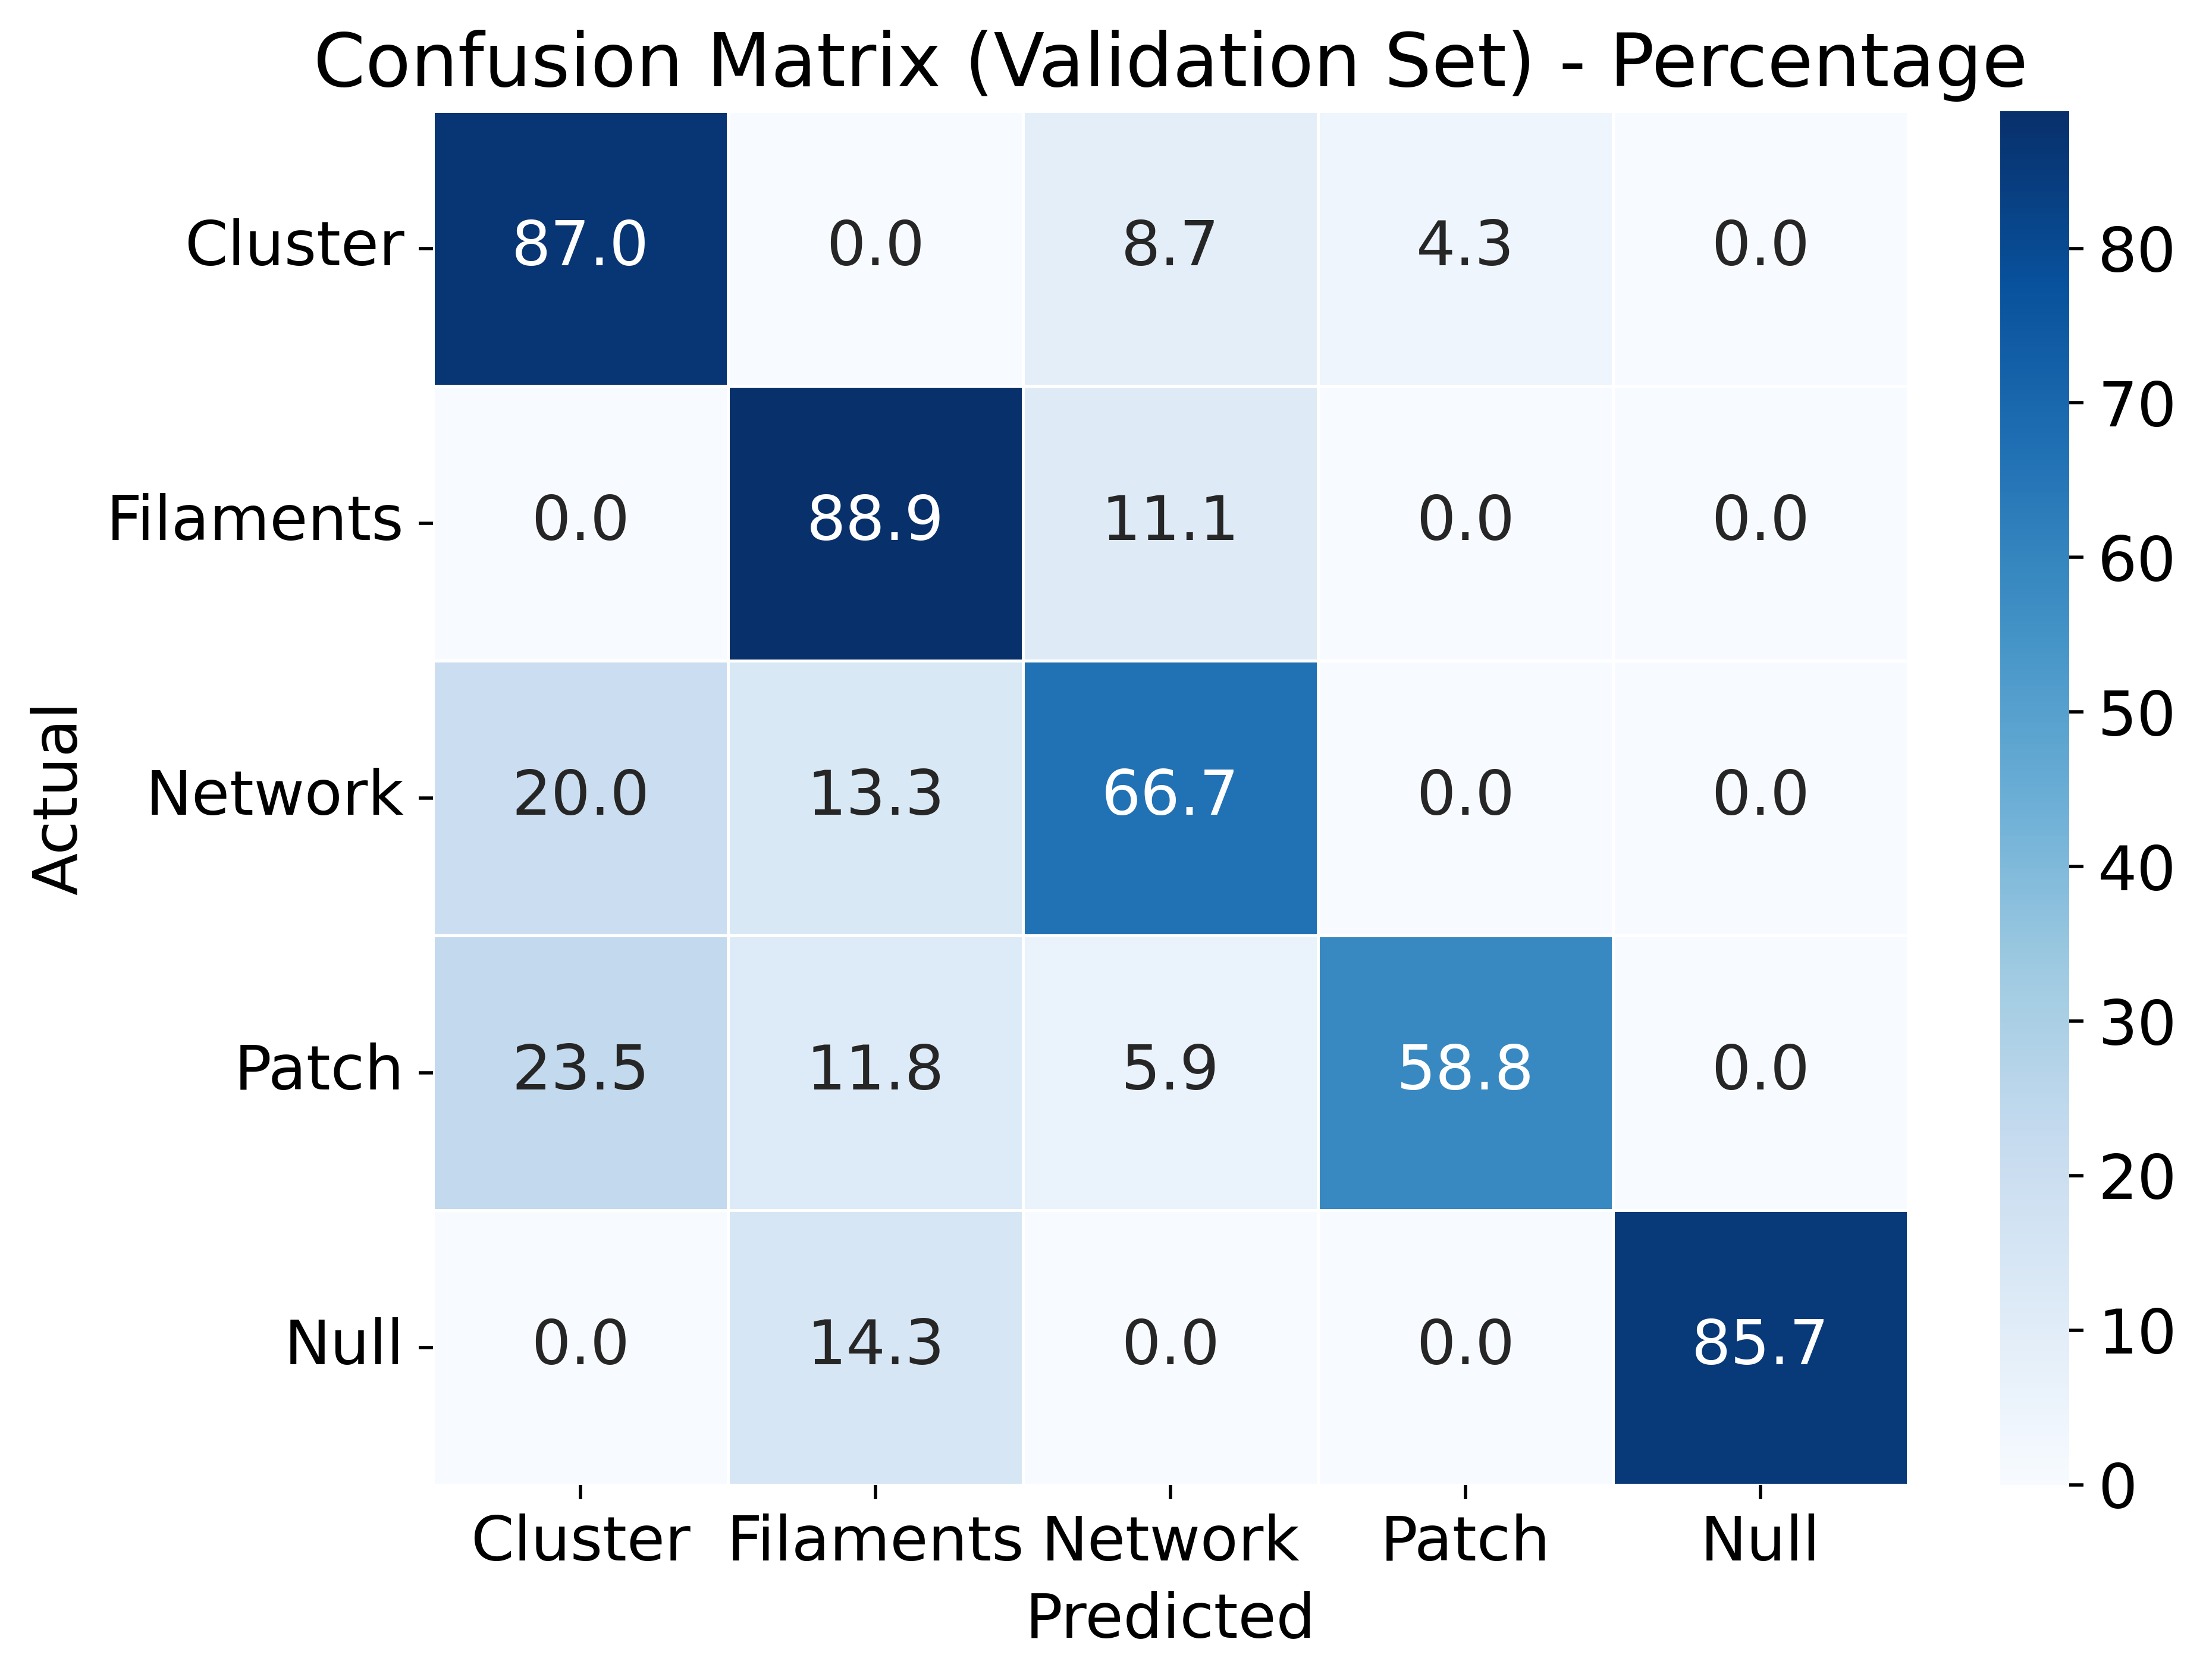

In [8]:
import numpy as np
import matplotlib
matplotlib.rcParams['font.size'] = 15

model.load_state_dict(torch.load(os.path.join(output_dir,"cleanning_version_cellpose_best_model"+timestampstr+".pth")))
    
# Function to evaluate model and plot confusion matrix with percentages
def evaluate_model(dataloader, dataset_name, cm_outputdir):
    true_labels, pred_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())
    # # true_labels[true_labels=='ZZZ']='Null'
    # # pred_labels[pred_labels=='ZZZ']='Null'
    # print(true_labels)
    
    cm = confusion_matrix(true_labels, pred_labels)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convert to percentages
    labels = list(train_dataset.label_to_index.keys())
    labels[4]="Null"
    print(labels)
    cm_percent_df = pd.DataFrame(cm_percentage, index=labels, columns=labels)
    
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    
    plt.figure(figsize=(8, 6),dpi=500)
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.savefig(os.path.join(output_dir, dataset_name+timestampstr+"_cm_number.png"), dpi=500, bbox_inches='tight')

    plt.figure(figsize=(8, 6),dpi=500)
    sns.heatmap(cm_percent_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name}) - Percentage")
    plt.savefig(os.path.join(output_dir, dataset_name+timestampstr+"_cm_percent.png"), dpi=500, bbox_inches='tight')

    
evaluate_model(train_dataloader, "Training Set", output_dir)
evaluate_model(val_dataloader, "Validation Set", output_dir)